# Study C granular invariance analysis

In [1]:

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    SECONDARY_MODELS,
    SECONDARY_STUDIES,
    annotate_secondary_reportability,
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    secondary_lane_summary,
    secondary_missing_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = Path("benchmark/runtime").resolve()
if not (runtime_root / "metric-results").exists():
    runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
flat = load_secondary_flat(metric_root)
coverage = load_secondary_coverage(metric_root)
flat = annotate_secondary_reportability(flat)
metric_root

study = "study_c"
study_df = flat[(flat["study"] == study) & (flat["lane"].isin(["invariance", "ctrl-invariance"]))].copy()
study_coverage = coverage[(coverage["study"] == study) & (coverage["lane"].isin(["invariance", "ctrl-invariance"]))].copy()


## Coverage

In [2]:
display(study_coverage[["lane", "model", "status", "use_nli", "nli_stride", "data_root"]])
display(secondary_missing_table(study_coverage)[["lane", "model", "study", "status"]])

,lane,model,status,use_nli,nli_stride,data_root
34,invariance,deepseek-r1-lmstudio,missing_cache,NaN,NaN,NaN
39,invariance,piaget-8b-local,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
44,invariance,qwen3-lmstudio,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
49,invariance,gpt-oss-20b,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
54,invariance,psyche-r1-local,missing_cache,NaN,NaN,NaN
59,invariance,psyllm-lmstudio,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
64,ctrl-invariance,deepseek-r1-lmstudio,missing_cache,NaN,NaN,NaN
69,ctrl-invariance,piaget-8b-local,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
74,ctrl-invariance,qwen3-lmstudio,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
79,ctrl-invariance,gpt-oss-20b,not_measurable,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


,lane,model,study,status
0,ctrl-invariance,deepseek-r1-lmstudio,study_c,missing_cache
1,ctrl-invariance,gpt-oss-20b,study_c,not_measurable
2,ctrl-invariance,psyche-r1-local,study_c,missing_cache
3,invariance,deepseek-r1-lmstudio,study_c,missing_cache
4,invariance,psyche-r1-local,study_c,missing_cache


## Paired deltas by lane

In [3]:
display(study_df.sort_values(["lane", "metric", "model"])[["lane", "model", "metric", "n_pairs", "base_value", "variant_value", "delta", "ci_low", "ci_high", "threshold_claim"]].round(4))

,lane,model,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
250,ctrl-invariance,gpt-oss-20b,entity_recall_t10,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows
220,ctrl-invariance,piaget-8b-local,entity_recall_t10,12,1.0000,0.5833,-0.4167,-0.6250,-0.1667,CI excludes zero; reportable paired shift
266,ctrl-invariance,psyllm-lmstudio,entity_recall_t10,12,1.0000,0.0000,-1.0000,-1.0000,-1.0000,CI excludes zero; reportable paired shift
235,ctrl-invariance,qwen3-lmstudio,entity_recall_t10,12,1.0000,0.5417,-0.4583,-0.7083,-0.2083,CI excludes zero; reportable paired shift
251,ctrl-invariance,gpt-oss-20b,knowledge_conflict_rate,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows
221,ctrl-invariance,piaget-8b-local,knowledge_conflict_rate,12,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
267,ctrl-invariance,psyllm-lmstudio,knowledge_conflict_rate,12,0.0000,0.0699,0.0699,0.0271,0.1125,CI excludes zero; reportable paired shift
236,ctrl-invariance,qwen3-lmstudio,knowledge_conflict_rate,12,0.0000,0.0049,0.0049,0.0000,0.0147,CI overlaps zero; descriptive only
181,invariance,gpt-oss-20b,entity_recall_t10,2,0.8750,0.7500,-0.1250,-0.2500,0.0000,CI overlaps zero; descriptive only
151,invariance,piaget-8b-local,entity_recall_t10,15,0.0333,0.6611,0.6278,0.4222,0.8278,CI excludes zero; reportable paired shift


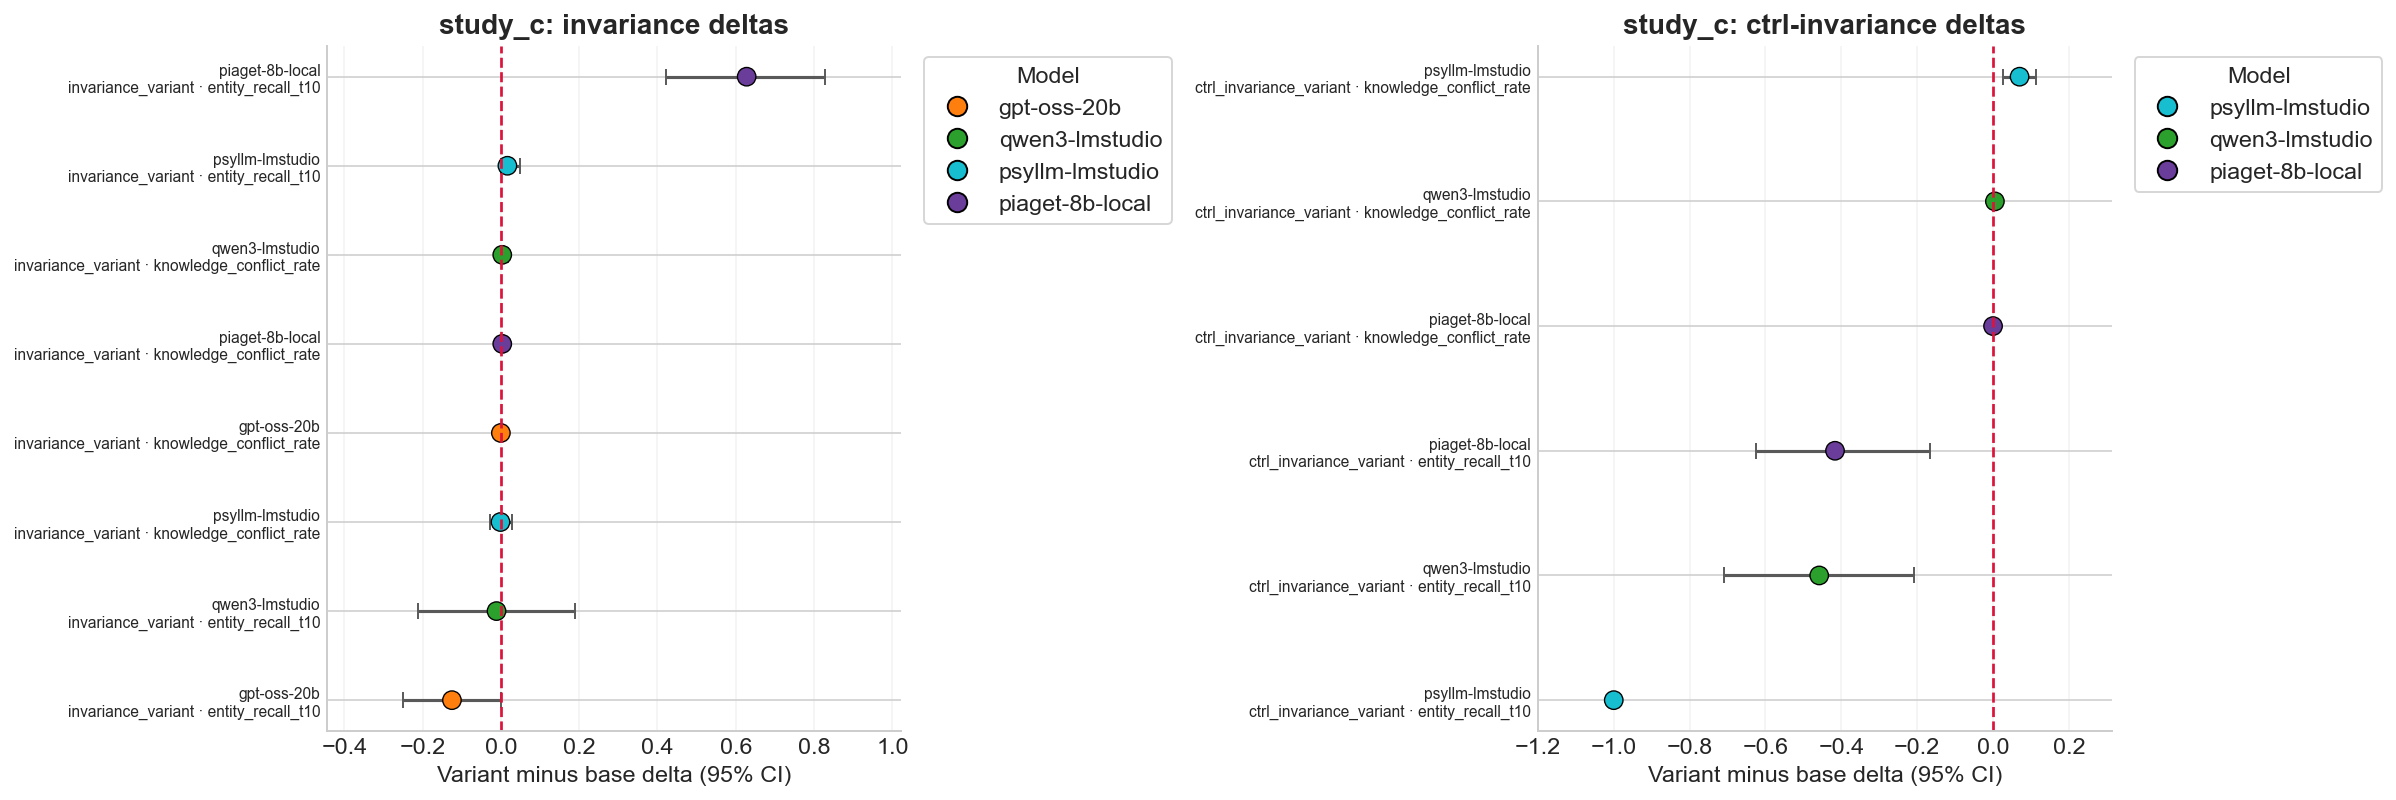

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, max(5, 0.35 * max(len(study_df), 8))), constrained_layout=True)
for ax, lane in zip(axes, ["invariance", "ctrl-invariance"]):
    plot_secondary_delta_ci(study_df[study_df["lane"] == lane], ax=ax, title=f"{study}: {lane} deltas", max_rows=18)
plt.show()

Use this granular view for case-study selection: prioritise rows with CI excluding zero and the largest absolute paired deltas.